In [1]:
import random
from typing import Literal
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

from typing_extensions import TypedDict
import random
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated

from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
class State(TypedDict):
    graph_state: str

In [3]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

In [4]:
builder = StateGraph(State)

builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", 'node_2')
builder.add_edge("node_2", END)
graph = builder.compile()

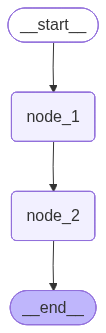

In [5]:
graph  

In [6]:
y = graph.invoke({"graph_state" : "Hi, this is Lance."})

---Node 1---
---Node 2---


In [7]:
y

{'graph_state': 'Hi, this is Lance. I am happy!'}

### Conditional edges

In [8]:
class State(TypedDict):
    graph_state: str

In [9]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

In [10]:

def decide_mood(state):
    if random.random() < 0.5:
        return "test_2"
    else:
        return "test_3"

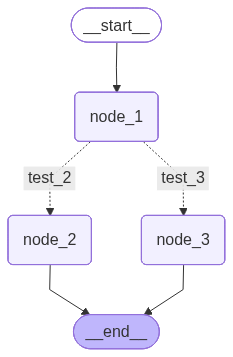

In [11]:
builder = StateGraph(State)

builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood, {"test_2":"node_2", "test_3":"node_3"})
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)
graph = builder.compile()

graph

In [14]:
y = graph.invoke({"graph_state" : "Hi, this is Lance."})
y

---Node 1---
---Node 2---


{'graph_state': 'Hi, this is Lance. I am happy!'}

## Parallel processing

In [15]:
class state(TypedDict):
    state_1: str
    state_2: str

In [ ]:
def first_node(state):

    return {"state_1": state['state_1'] +"added this extra line of code to state 1"}


def second_node(state):

    return  {"state_2": state['state_2'] +"added this extra line of code to state 2"}

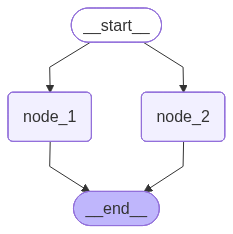

In [17]:
builder = StateGraph(state)

builder.add_node("node_1", first_node)

builder.add_node("node_2", second_node)

builder.add_edge(START, "node_1")
builder.add_edge(START, "node_2")

builder.add_edge("node_1", END)
builder.add_edge("node_2", END)

graph = builder.compile()
graph

In [19]:
outpt = graph.invoke({"state_1" : "Hi, this is Lance.", "state_2" : "Hi, this is John."})
outpt

{'state_1': 'Hi, this is Lance.added this extra line of code to state 1',
 'state_2': 'Hi, this is John.added this extra line of code to state 2'}

## Dynamic routing

In [8]:
class state(TypedDict):
    state_1: str
    state_2: str
    state_3: str

In [9]:
def first_node(state):

    return {"state_1": state['state_1'] +"added this extra line of code to state 1"}


def second_node(state):

    return  {"state_2": state['state_2'] +"added this extra line of code to state 2"}

def third_node(state):

    return  {"state_3": state['state_3'] +"added this extra line of code to state 3"}

In [11]:
def decide(state):

    if random.random()<0.5:
        return ["node_1", "node_2"]
    else:
        return ["node_1", "node_3"]

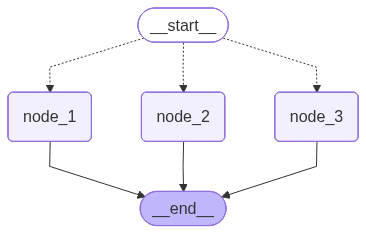

In [12]:
builder = StateGraph(state)

builder.add_node("node_1", first_node)
builder.add_node("node_2", second_node)
builder.add_node("node_3", third_node)

builder.add_conditional_edges(START, decide, ["node_1", "node_2", "node_3"])

builder.add_edge("node_1", END)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

graph = builder.compile()

graph

In [13]:
outpt = graph.invoke({"state_1" : "Hi, this is Lance.", "state_2" : "Hi, this is John.", "state_3": "Hi, This is michael"})
outpt

{'state_1': 'Hi, this is Lance.added this extra line of code to state 1',
 'state_2': 'Hi, this is John.added this extra line of code to state 2',
 'state_3': 'Hi, This is michael'}

## Reducers

In [2]:
from typing import TypedDict, Annotated
from operator import add

- Error case

In [3]:
class state(TypedDict):
    state_1: int
    state_2: int

def first_node(state):

    return {"state_1": 1}


def second_node(state):

    return  {"state_1": 10}


def third_node(state):

    return  {"state_2": 2}

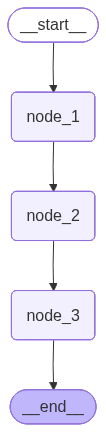

In [4]:
builder = StateGraph(state)

builder.add_node("node_1", first_node)
builder.add_node("node_2", second_node)

builder.add_node("node_3", third_node)

builder.add_edge(START, "node_1")
builder.add_edge('node_1', "node_2")


builder.add_edge("node_2", "node_3")

builder.add_edge("node_3", END)



graph = builder.compile()

graph

In [5]:
output = graph.invoke({"state_1":1})

In [6]:
output

{'state_1': 10, 'state_2': 2}

In [7]:
class state(TypedDict):
    state_1: Annotated[list, add] 
    state_2: int

In [8]:
def first_node(state):

    return {"state_1": [1]}


def second_node(state):

    return  {"state_1": [10]}


def third_node(state):

    return  {"state_2": sum(state['state_1'])}

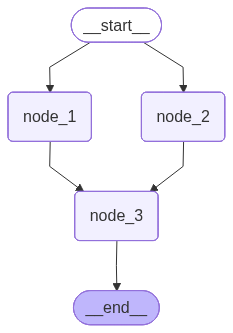

In [9]:
builder = StateGraph(state)

builder.add_node("node_1", first_node)
builder.add_node("node_2", second_node)

builder.add_node("node_3", third_node)

builder.add_edge(START, "node_1")
builder.add_edge(START, "node_2")

builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", "node_3")

builder.add_edge("node_3", END)

graph = builder.compile()

graph

In [10]:
output = graph.invoke({"state_1":[1]})

output

{'state_1': [1, 1, 10], 'state_2': 12}

## Memory

In [32]:
mixtral = 'mixtral-8x7b-32768'
llama = 'llama-3.3-70b-versatile'

llm = ChatGroq(temperature=0, model_name=llama)

In [33]:
template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful AI assistant that assists humans on any topic. Answer in 30 words",
        ),
        ("human", "{user_input}"),
    ]
)

chain = template | llm

templat_summarize = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            '''You are a helpful AI assistant that summarizes the conversation without losing key topics in original text.
              Make sure every topic is included. Just summarize the discussion around that topic.
            ''',
        ),
        ("human", "{user_input}"),
    ]
)


chain_summarize = templat_summarize | llm

In [34]:
class CustomMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [ ]:
def node1(state: CustomMessagesState):

    x = chain.invoke({"user_input": state["messages"]})
    msg = AIMessage(content=x.content)
    return {"messages": [msg]}  # append to existing messages

def summarize_chain(state: CustomMessagesState):
    summary = chain_summarize.invoke({"user_input": state["messages"]})
    msg = AIMessage(content=summary.content)
    return {"messages": state["messages"] + [msg]}

def check_summary(state: CustomMessagesState):

    if len(state["messages"]) > 6:
        return "summarize_convo"
    else:
        return "normal_memory"

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
builder = StateGraph(CustomMessagesState)

builder.add_node("llm_response", node1)
builder.add_node("summarize_chain", summarize_chain)

builder.add_edge(START, "llm_response")

builder.add_conditional_edges(
    "llm_response",
    check_summary,
    {
        "summarize_convo": "summarize_chain",
        "normal_memory": END,
    },
)

builder.add_edge("summarize_chain", END)

# Add memory persistence

memory = MemorySaver()
graph = builder.compile(checkpointer=memory) 
#The state (messages) only lives in RAM during one execution of the graph.
#With memory:
#The graph checkpoints state between runs.

#When you call graph.invoke() again with the same thread_id (or session key), LangGraph loads the previous messages state from memory.

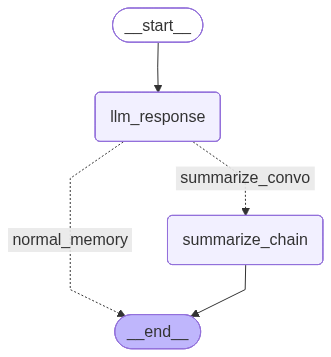

In [39]:
graph 


## Callbacks

- Callbacks are observers, not controllers of execution

In [11]:
from langchain_core.callbacks import BaseCallbackHandler

In [13]:

class PrintCallbackHandler(BaseCallbackHandler):
    def __init__(self):
        super().__init__()
        # Track run_id to node_name mapping
        self.run_id_to_node = {}
    
    def _resolve_name(self, serialized, kwargs):
        # First check if we have the run_id tracked from a start event
        run_id = kwargs.get("run_id")
        if run_id and run_id in self.run_id_to_node:
            return self.run_id_to_node[run_id]
        
        # Check if name is directly in kwargs
        if "name" in kwargs:
            return kwargs["name"]
        
        # Check metadata for langgraph_node
        if "metadata" in kwargs and kwargs["metadata"]:
            node_name = kwargs["metadata"].get("langgraph_node")
            if node_name:
                return node_name
        
        # Special case: if it's a top-level event with no parent_run_id, it's likely the main graph
        if kwargs.get("parent_run_id") is None and not kwargs.get("tags"):
            return "LangGraph"
        
        # Fallback to serialized info
        if serialized:
            return serialized.get("name", serialized.get("id", ["<unknown>"])[-1])
        
        return "<unknown>"

    def on_chain_start(self, serialized, inputs, **kwargs):
        name = self._resolve_name(serialized, kwargs)
        
        # Store the mapping for this run_id if it's a node
        run_id = kwargs.get("run_id")
        if run_id and "metadata" in kwargs and kwargs["metadata"].get("langgraph_node"):
            self.run_id_to_node[run_id] = kwargs["metadata"]["langgraph_node"]
        
        print(f"[CALLBACK] Start | name={name} | inputs={inputs}")

    def on_chain_end(self, outputs, serialized=None, **kwargs):
        name = self._resolve_name(serialized, kwargs)
        print(f"[CALLBACK] End   | name={name} | outputs={outputs}")
        
        # Clean up the mapping to avoid memory leaks
        run_id = kwargs.get("run_id")
        if run_id and run_id in self.run_id_to_node:
            del self.run_id_to_node[run_id]

    def on_chain_error(self, error, serialized=None, **kwargs):
        name = self._resolve_name(serialized, kwargs)
        print(f"[CALLBACK] Error | name={name} | error={error}")
        
        # Clean up the mapping
        run_id = kwargs.get("run_id")
        if run_id and run_id in self.run_id_to_node:
            del self.run_id_to_node[run_id]

In [ ]:

class State(TypedDict):
    text: str




# --- Define nodes ---
def node_1(state: State) -> State:
    
    
    return {"text": state["text"] + " -> node_1"}

def node_2(state: State) -> State:
    return {"text": state["text"] + " -> node_2"}


# --- Build graph ---
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.set_entry_point("node_1")
builder.add_edge("node_1", "node_2")

compiled_graph = builder.compile()
graph_with_callbacks = compiled_graph.with_config({"callbacks": [PrintCallbackHandler()]})
result = graph_with_callbacks.invoke({"text": "Start"})

[CALLBACK] Start | name=LangGraph | inputs={'text': 'Start'}
[CALLBACK] Start | name=node_1 | inputs={'text': 'Start'}
[CALLBACK] End   | name=node_1 | outputs={'text': 'Start -> node_1'}
[CALLBACK] Start | name=node_2 | inputs={'text': 'Start -> node_1'}
[CALLBACK] End   | name=node_2 | outputs={'text': 'Start -> node_1 -> node_2'}
[CALLBACK] End   | name=LangGraph | outputs={'text': 'Start -> node_1 -> node_2'}


## LLM callbacks

In [15]:
class State(TypedDict):
    text: str

In [16]:

# --- Initialize LLM ---
llama = 'llama-3.3-70b-versatile'
llm = ChatGroq(temperature=0, model_name=llama)


# --- Define nodes with LLM calls ---
def node_1(state: State) -> State:
    # Create a prompt based on the current text
    prompt = f"Based on this text: '{state['text']}', write a creative continuation in exactly 10 words."
    
    # Make LLM call
    response = llm.invoke([HumanMessage(content=prompt)])
    
    return {"text": state["text"] + " -> node_1: " + response.content}

def node_2(state: State) -> State:
    # Create a different prompt for node 2
    prompt = f"Summarize this story in exactly 8 words: '{state['text']}'"
    
    # Make LLM call
    response = llm.invoke([HumanMessage(content=prompt)])
    
    return {"text": state["text"] + " -> node_2: " + response.content}

In [17]:
class PrintCallbackHandler(BaseCallbackHandler):
    def __init__(self):
        super().__init__()
        # Track run_id to node_name mapping
        self.run_id_to_node = {}
    
    def _resolve_name(self, serialized, kwargs):
        # First check if we have the run_id tracked from a start event
        run_id = kwargs.get("run_id")
        if run_id and run_id in self.run_id_to_node:
            return self.run_id_to_node[run_id]
        
        # Check if name is directly in kwargs
        if "name" in kwargs:
            return kwargs["name"]
        
        # Check metadata for langgraph_node
        if "metadata" in kwargs and kwargs["metadata"]:
            node_name = kwargs["metadata"].get("langgraph_node")
            if node_name:
                return node_name
        
        # Special case: if it's a top-level event with no parent_run_id, it's likely the main graph
        if kwargs.get("parent_run_id") is None and not kwargs.get("tags"):
            return "LangGraph"
        
        # Fallback to serialized info
        if serialized:
            return serialized.get("name", serialized.get("id", ["<unknown>"])[-1])
        
        return "<unknown>"

    def on_chain_start(self, serialized, inputs, **kwargs):
        name = self._resolve_name(serialized, kwargs)
        
        # Store the mapping for this run_id if it's a node
        run_id = kwargs.get("run_id")
        if run_id and "metadata" in kwargs and kwargs["metadata"].get("langgraph_node"):
            self.run_id_to_node[run_id] = kwargs["metadata"]["langgraph_node"]
        
        print(f"[CALLBACK] Start | name={name} | inputs={inputs}")

    def on_chain_end(self, outputs, serialized=None, **kwargs):
        name = self._resolve_name(serialized, kwargs)
        print(f"[CALLBACK] End   | name={name} | outputs={outputs}")
        
        # Clean up the mapping to avoid memory leaks
        run_id = kwargs.get("run_id")
        if run_id and run_id in self.run_id_to_node:
            del self.run_id_to_node[run_id]

    def on_chain_error(self, error, serialized=None, **kwargs):
        name = self._resolve_name(serialized, kwargs)
        print(f"[CALLBACK] Error | name={name} | error={error}")
        
        # Clean up the mapping
        run_id = kwargs.get("run_id")
        if run_id and run_id in self.run_id_to_node:
            del self.run_id_to_node[run_id]

    # --- LLM-specific callbacks ---
    def on_llm_start(self, serialized, prompts, **kwargs):
        name = self._resolve_name(serialized, kwargs)
        print(f"[LLM CALLBACK] Start | name={name} | prompts={prompts}")

    def on_llm_end(self, response, **kwargs):
        name = self._resolve_name({}, kwargs)
        print(f"[LLM CALLBACK] End   | name={name} | response={response}")

    def on_llm_error(self, error, **kwargs):
        name = self._resolve_name({}, kwargs)
        print(f"[LLM CALLBACK] Error | name={name} | error={error}")

    def on_llm_new_token(self, token, **kwargs):
        """Called when LLM streams a new token (if streaming is enabled)"""
        name = self._resolve_name({}, kwargs)
        print(f"[LLM CALLBACK] Token | name={name} | token='{token}'")

In [18]:
# --- Build graph ---
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.set_entry_point("node_1")
builder.add_edge("node_1", "node_2")

compiled_graph = builder.compile()
graph_with_callbacks = compiled_graph.with_config({"callbacks": [PrintCallbackHandler()]})

In [19]:
result = graph_with_callbacks.invoke({"text": "Start"})

[CALLBACK] Start | name=LangGraph | inputs={'text': 'Start'}
[CALLBACK] Start | name=node_1 | inputs={'text': 'Start'}
[LLM CALLBACK] Start | name=None | prompts=["Human: Based on this text: 'Start', write a creative continuation in exactly 10 words."]
[LLM CALLBACK] End   | name=<unknown> | response=generations=[[ChatGeneration(text='The journey begins with a single courageous forward step.', generation_info={'finish_reason': 'stop', 'logprobs': None}, message=AIMessage(content='The journey begins with a single courageous forward step.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 53, 'total_tokens': 64, 'completion_time': 0.061802863, 'prompt_time': 0.01186433, 'queue_time': 0.04729341, 'total_time': 0.073667193}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3f3b593e33', 'finish_reason': 'stop', 'logprobs': None}, id='run-2df2defa-1778-45d8-8abf-71f1d046133c-0', usage_metadata={'input_tokens': 53, 'output_to